In [1]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from typing import List

# Locals
from utils import *
from dataset import Dataset, SlidingWindowDataset
from models import *
from dlnr import DLNoiseReduction

In [3]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

# Functions

In [5]:
def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

# Load data

In [6]:
df = pd.read_csv(os.path.join(DATA_PATH, 'Informer_Datasets', 'WTH', 'WTH.csv'))[:1000]
df

,date,Visibility,DryBulbFarenheit,DryBulbCelsius,WetBulbFarenheit,DewPointFarenheit,DewPointCelsius,RelativeHumidity,WindSpeed,WindDirection,StationPressure,Altimeter,WetBulbCelsius
0,1/1/2010 0:00,10.0,16,-9,13,7,-14,67,7,130,21.65,30.35,-10.3
1,1/1/2010 1:00,10.0,16,-9,13,7,-14,67,5,150,21.64,30.34,-10.3
2,1/1/2010 2:00,10.0,16,-9,13,7,-14,67,5,190,21.65,30.35,-10.3
3,1/1/2010 3:00,10.0,16,-9,13,7,-14,67,7,180,21.65,30.35,-10.3
4,1/1/2010 4:00,10.0,16,-9,14,9,-13,74,6,120,21.64,30.34,-10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2/11/2010 11:00,10.0,28,-2,22,10,-12,47,3,330,21.34,29.95,-5.6
996,2/11/2010 12:00,10.0,27,-3,21,10,-12,49,7,340,21.33,29.94,-6.0
997,2/11/2010 13:00,10.0,27,-3,22,14,-10,58,9,300,21.33,29.94,-5.3
998,2/11/2010 14:00,10.0,27,-3,23,16,-9,63,11,310,21.34,29.95,-5.0


In [7]:
df.index = pd.to_datetime(df['date'])
df.drop(columns=['date'], inplace=True)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Visibility,1000.0,9.03850,2.476722,0.25,10.00,10.00,10.0000,10.00
DryBulbFarenheit,1000.0,27.01200,7.288551,0.00,21.00,27.00,32.0000,46.00
DryBulbCelsius,1000.0,-2.64500,3.842882,-14.00,-5.00,-2.00,0.0000,8.00
WetBulbFarenheit,1000.0,22.38800,5.880479,0.00,19.00,23.00,27.0000,33.00
DewPointFarenheit,1000.0,13.57200,8.984628,-18.00,9.00,14.00,19.0000,32.00
DewPointCelsius,1000.0,-10.10600,4.999376,-28.00,-13.00,-10.00,-6.0000,0.00
RelativeHumidity,1000.0,60.36200,21.312794,0.00,45.00,63.00,76.2500,100.00
WindSpeed,1000.0,4.58800,3.753711,0.00,0.00,5.00,7.0000,17.00
WindDirection,1000.0,145.32100,113.510319,0.00,0.00,150.00,280.0000,350.00
StationPressure,1000.0,21.38698,0.178886,20.85,21.31,21.39,21.5200,21.72


In [8]:
for col in df.columns:
    print(len(np.unique(df[col])))

14
24
23
30
28
28
81
15
30
84
109
123


<Axes: >

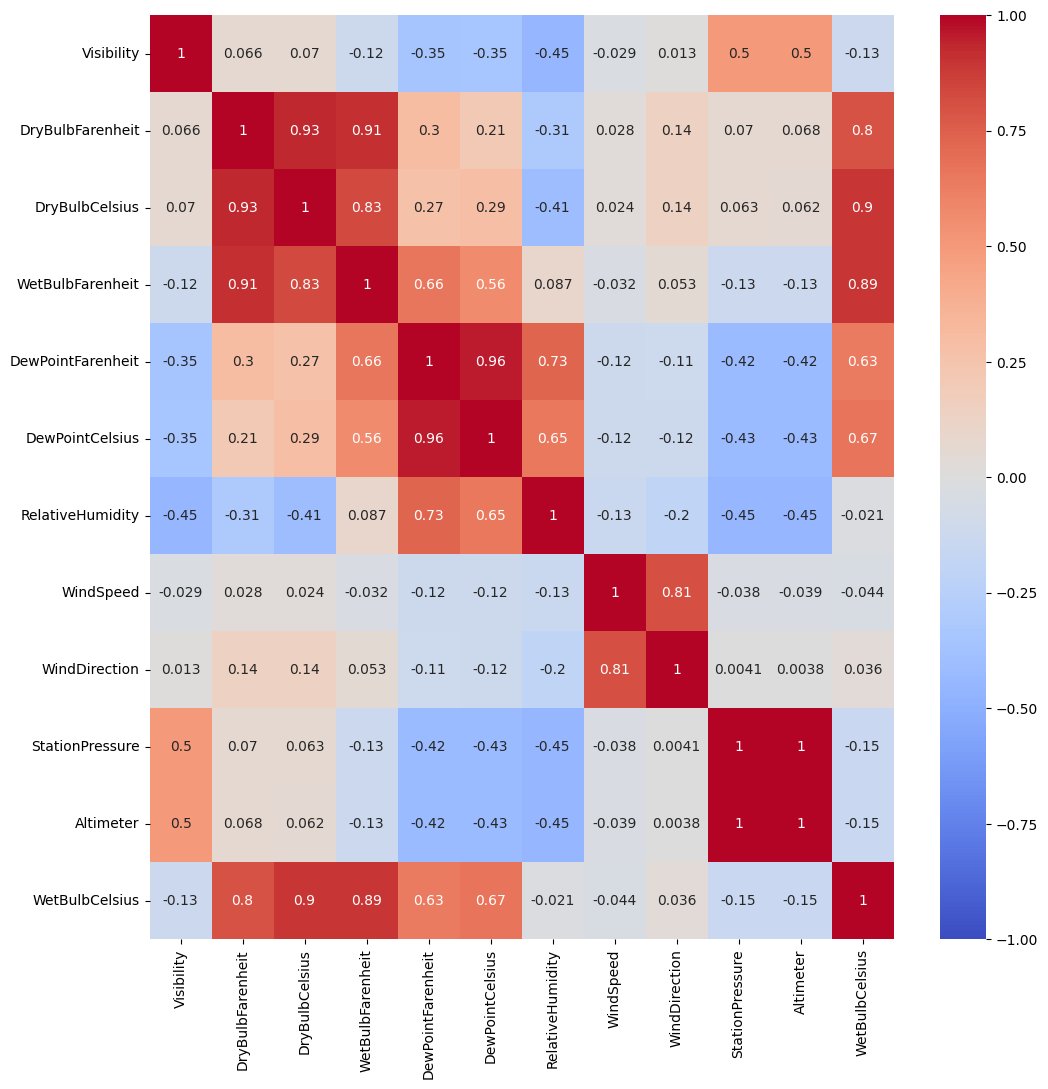

In [9]:
corr = df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [10]:
df_small = df[df.columns[1:6]]
df_small['y'] = df[df.columns[-1:]]

/tmp/ipykernel_2871797/2642242864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['y'] = df[df.columns[-1:]]


<Axes: >

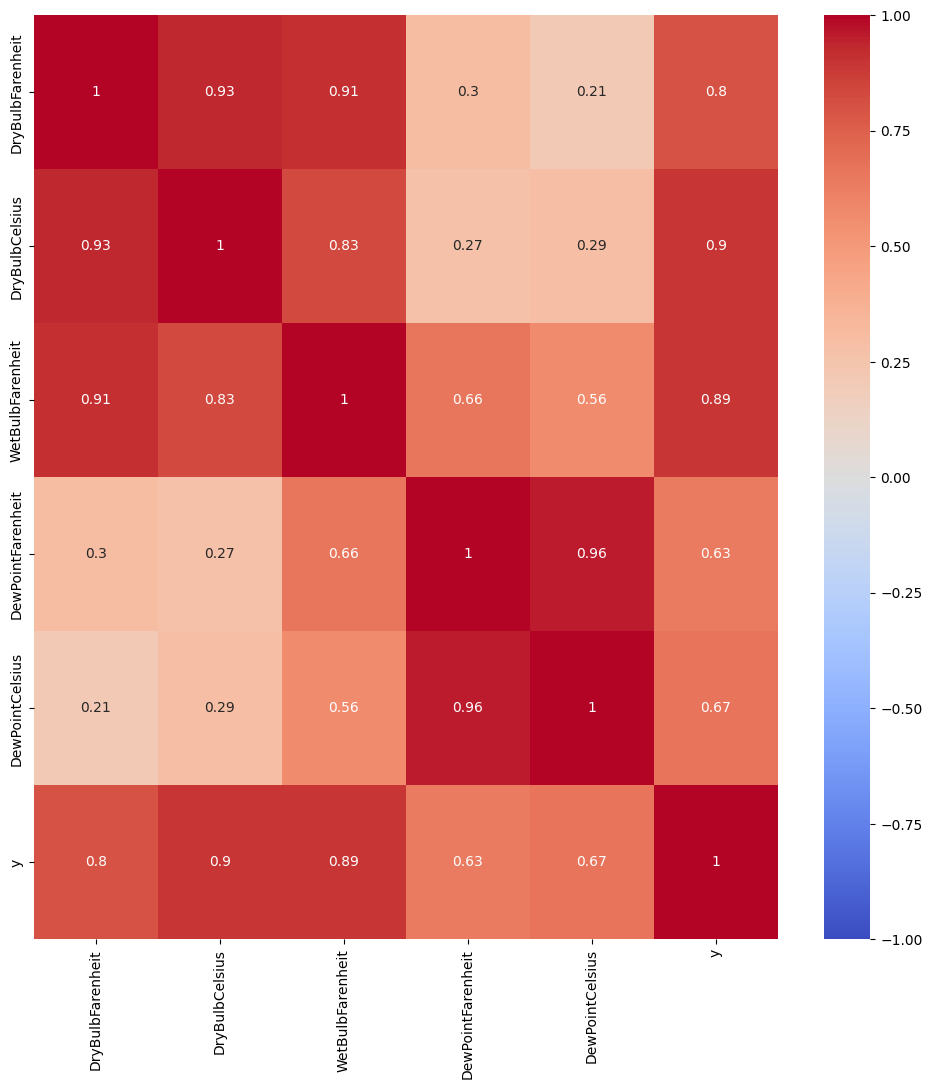

In [11]:
corr_orig = df_small.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_orig, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [12]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_small)
df_scaled = pd.DataFrame(df_scaled, columns=df_small.columns)
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
DryBulbFarenheit,1000.0,0.587217,0.158447,0.0,0.456522,0.586957,0.695652,1.0
DryBulbCelsius,1000.0,0.516136,0.174676,0.0,0.409091,0.545455,0.636364,1.0
WetBulbFarenheit,1000.0,0.678424,0.178196,0.0,0.575758,0.696970,0.818182,1.0
DewPointFarenheit,1000.0,0.631440,0.179693,0.0,0.540000,0.640000,0.740000,1.0
DewPointCelsius,1000.0,0.639071,0.178549,0.0,0.535714,0.642857,0.785714,1.0
y,1000.0,0.623519,0.199707,0.0,0.500000,0.653846,0.770833,1.0


In [13]:
sigma = 0.05
df_noisy = add_gaussian_noise(
        df=df_scaled.copy(),
        columns=[x for x in df_scaled.columns],
        mean=0,
        std=sigma
)
display(df_scaled.describe().T)
display(df_noisy.describe().T)

,count,mean,std,min,25%,50%,75%,max
DryBulbFarenheit,1000.0,0.587217,0.158447,0.0,0.456522,0.586957,0.695652,1.0
DryBulbCelsius,1000.0,0.516136,0.174676,0.0,0.409091,0.545455,0.636364,1.0
WetBulbFarenheit,1000.0,0.678424,0.178196,0.0,0.575758,0.696970,0.818182,1.0
DewPointFarenheit,1000.0,0.631440,0.179693,0.0,0.540000,0.640000,0.740000,1.0
DewPointCelsius,1000.0,0.639071,0.178549,0.0,0.535714,0.642857,0.785714,1.0
y,1000.0,0.623519,0.199707,0.0,0.500000,0.653846,0.770833,1.0


,count,mean,std,min,25%,50%,75%,max
DryBulbFarenheit,1000.0,0.586627,0.165699,-0.042214,0.482600,0.596989,0.688831,1.055637
DryBulbCelsius,1000.0,0.515972,0.180919,0.003989,0.397024,0.525262,0.637266,1.026770
WetBulbFarenheit,1000.0,0.677702,0.185676,-0.117527,0.563644,0.702498,0.815166,1.019927
DewPointFarenheit,1000.0,0.632869,0.186356,-0.022902,0.527966,0.650625,0.766967,1.042293
DewPointCelsius,1000.0,0.636693,0.187053,-0.022097,0.530536,0.652024,0.768811,1.095481
y,1000.0,0.624788,0.205265,-0.035997,0.492214,0.649912,0.777401,1.080613


<Axes: >

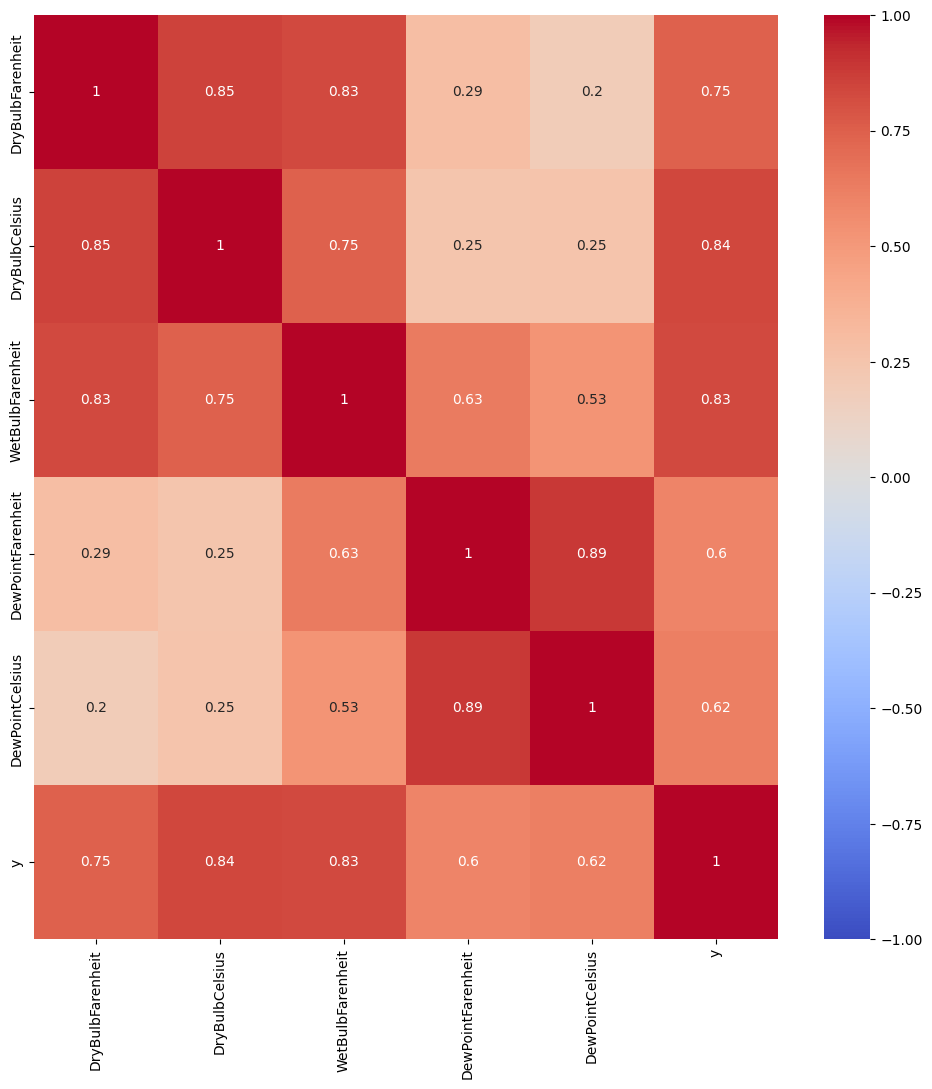

In [14]:
corr_noisy = df_noisy.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_noisy, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

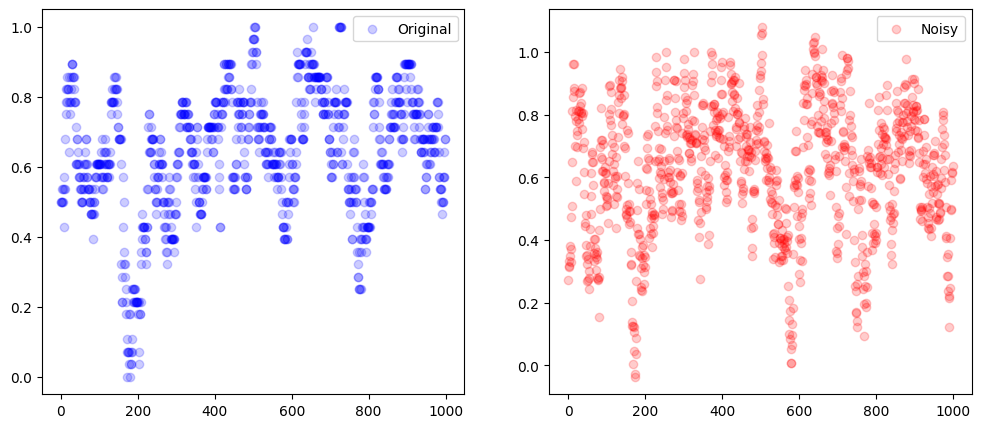

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(range(len(df_scaled['DewPointCelsius'])), df_scaled['DewPointCelsius'], alpha=0.2, c='b', label='Original')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(range(len(df_noisy['y'])), df_noisy['y'], alpha=0.2, c='r', label='Noisy')
plt.legend()

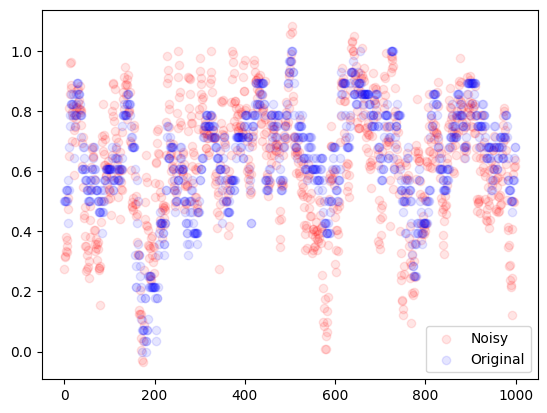

In [16]:
plt.scatter(range(len(df_noisy['y'])), df_noisy['y'], alpha=0.1, c='r', label='Noisy')
plt.scatter(range(len(df_scaled['DewPointCelsius'])), df_scaled['DewPointCelsius'], alpha=0.1, c='b', label='Original')
plt.legend()

In [17]:
# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_noisy[df_noisy.columns[:-1]], df_noisy[df_noisy.columns[-1]], test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [18]:
window_size = 24

In [19]:
train_dataset = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=1)
val_dataset = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=1)
test_dataset = SlidingWindowDataset(X_test, y_test, window_size=window_size, future=1)

In [20]:
input_size = X_train.shape[-1] * window_size # Número de variables de entrada
hidden_size = 128  # Número de neuronas en la capa oculta
output_size = 1  # Predicción de una variable

# Crear el modelo
model = DenseTemporalModel(input_size, hidden_size, output_size).to(device)

# Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()  # Error cuadrático medio
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [22]:
# Load checkpoint
# Comment if you want to train the model
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, 'WTH','dense_sigma0.1.pth')))

In [23]:
trainer = Trainer(
    model = model,
    train_generator = train_dataloader,
    val_generator = val_dataloader,
    device = device,
    criterion = criterion,
    optimizer = optimizer,
    epoch_scheduler = None,
    batch_scheduler = None,
    patience = 10,
    epochs = 500,
    checkpoints_path = os.path.join(CHECKPOINT_PATH, 'WTH', f'dense_sigma{sigma}'),
)

In [24]:
# Train the model
# Comment if you want to load the model
trainer.fit(verbose=True)

Training is started!


Epochs loop:   6%| | 30/500 [00:07<02:01,  3.88epoch/s, Train loss: 0.013308578049884988 - Val l

Training stopped as validation loss did not improve for 10 epochs.


(DenseTemporalModel(
   (flatten): Flatten(start_dim=1, end_dim=-1)
   (fc1): Linear(in_features=120, out_features=128, bias=True)
   (fc2): Linear(in_features=128, out_features=128, bias=True)
   (fc3): Linear(in_features=128, out_features=1, bias=True)
   (relu): ReLU()
 ),
 [0.09041761258592854,
  0.03153237134411738,
  0.0272518199469362,
  0.02284242911869055,
  0.019503579583841486,
  0.017758058746913812,
  0.016360162914573373,
  0.015202493007693971,
  0.014839441261508247,
  0.014737381757079782,
  0.014795125667731484,
  0.015464958117960335,
  0.016487254398306467,
  0.01816737460722397,
  0.02168509984606659,
  0.026131801524913158,
  0.032827694646336815,
  0.038010783741468344,
  0.03632682433666347,
  0.030248470193186362,
  0.02310012878438869,
  0.01795395149232505,
  0.015989079164316904,
  0.015379950767020126,
  0.014870686456561089,
  0.01436903772803096,
  0.013977666609231141,
  0.013704380274496296,
  0.013453089928423817,
  0.013299101467740226,
  0.0133085780

In [25]:
predictions = trainer.eval_dataloader(test_dataloader)
len(predictions)

6

In [26]:
predictions_flattened = np.array([y.cpu().detach().numpy() for x in predictions for y in x])
len(predictions_flattened)

176

In [27]:
predictions_train = trainer.eval_dataloader(train_dataloader)
len(predictions_train)

20

In [28]:
predictions_train_flattened = np.array([y.cpu().detach().numpy() for x in predictions_train for y in x])
len(predictions_train_flattened)

616

In [29]:
test_to_compare = y_test.values[window_size:]

In [30]:
mse = mean_squared_error(test_to_compare, predictions_flattened)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_to_compare, predictions_flattened)
r2 = r2_score(test_to_compare, predictions_flattened)

In [31]:
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2: {r2:.4f}')

MSE: 0.0071
RMSE: 0.0845
MAE: 0.0685
R2: 0.7336


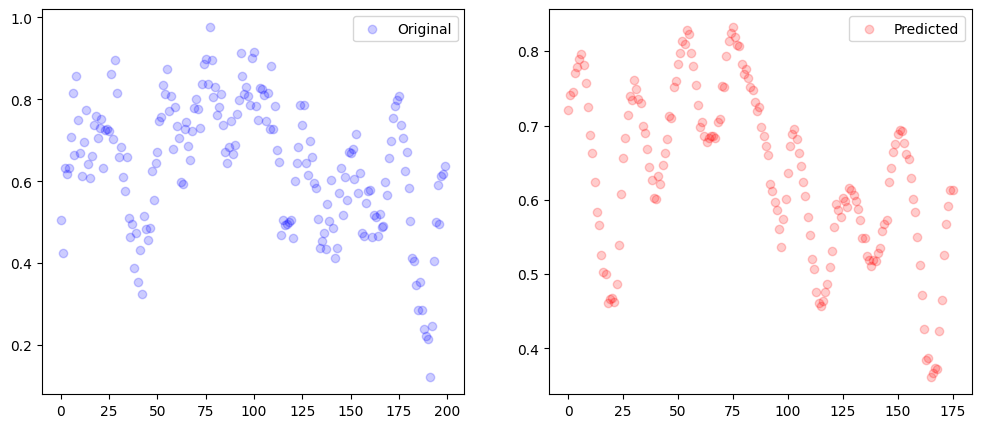

In [32]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(range(len(y_test)), y_test, alpha=0.2, c='b', label='Original')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(range(len(predictions_flattened)), predictions_flattened, alpha=0.2, c='r', label='Predicted')
plt.legend()

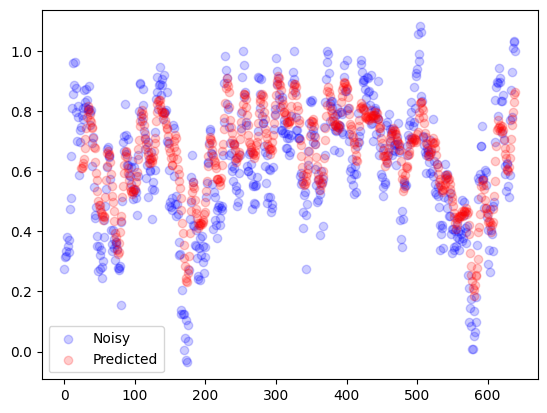

In [33]:
plt.scatter(range(len(y_train)), y_train, alpha=0.2, c='b', label='Noisy')
plt.scatter(range(window_size, len(y_train)), predictions_train_flattened, alpha=0.2, c='r', label='Predicted')
plt.legend()

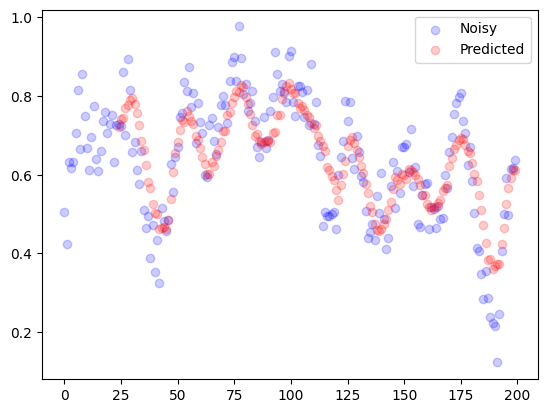

In [34]:
plt.scatter(range(len(y_test)), y_test, alpha=0.2, c='b', label='Noisy')
plt.scatter(range(window_size, len(y_test)), predictions_flattened, alpha=0.2, c='r', label='Predicted')
plt.legend()

# Gradients to reduce noise

In [56]:
x_cols = df_noisy.columns[:-1]
df_to_denoise = SlidingWindowDataset(df_noisy[x_cols], df_noisy[['y']], window_size=window_size, future=1)
# df_to_denoise = DataLoader(df_to_denoise, batch_size=len(df_to_denoise), shuffle=False)

In [57]:
dlnr = DLNoiseReduction(model=model, criterion=criterion, is_ts=True)
dlnr.fit(df_to_denoise)

In [58]:
a = np.array(range(25))

In [59]:
X_denoised, y_denoised = dlnr.transform(
    nrr=0.01,
    nr_threshold=0.05,
    max_epochs=500,
    plot_progress=False
)

 23%|███████████▎                                      | 110288/488000 [06:10<21:08, 297.76it/s]


In [60]:
scaler2 = MinMaxScaler()
y_denoised = scaler2.fit_transform(y_denoised)

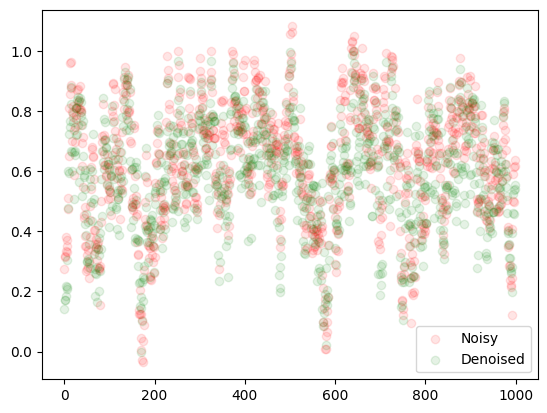

In [61]:
plt.scatter(range(len(df_noisy['y'])), df_noisy['y'], alpha=0.1, c='r', label='Noisy')
plt.scatter(range(len(y_denoised)), y_denoised, alpha=0.1, c='g', label='Denoised')
plt.legend()

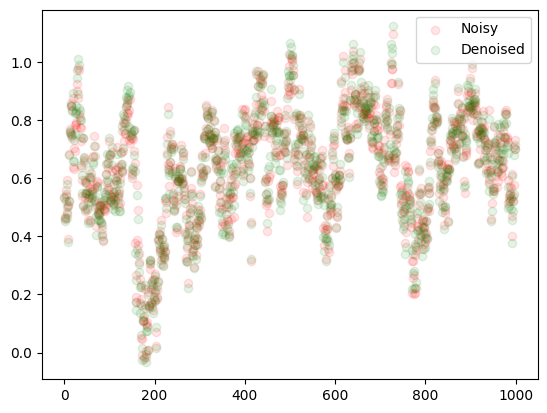

In [62]:
plt.scatter(range(len(df_noisy[df_noisy.columns[4]])), df_noisy[df_noisy.columns[4]], alpha=0.1, c='r', label='Noisy')
plt.scatter(range(len(X_denoised[X_denoised.columns[4]])), X_denoised[X_denoised.columns[4]], alpha=0.1, c='g', label='Denoised')
plt.legend()

<Axes: >

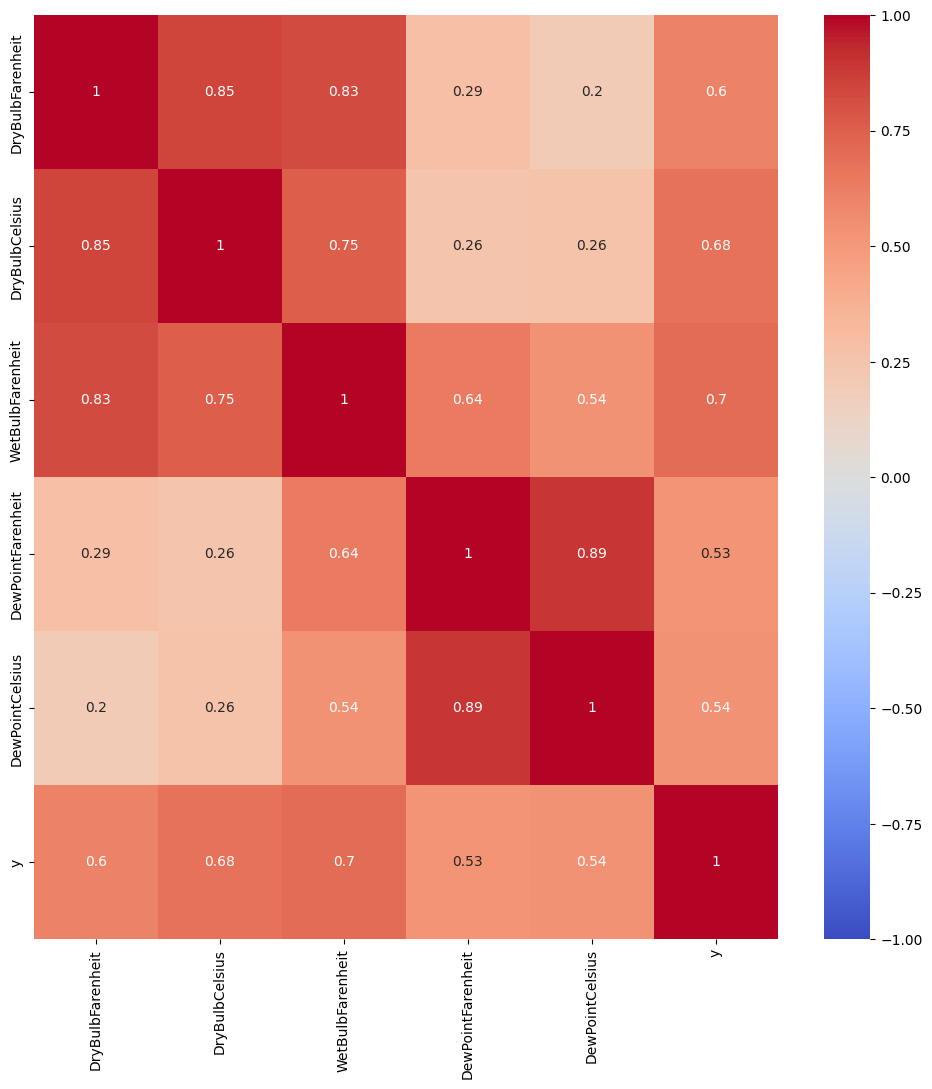

In [63]:
total_denoise = pd.concat([X_denoised[:4000], pd.DataFrame(y_denoised[:4000], columns=['y'])], axis=1)
corr_denoised = pd.DataFrame(total_denoise).corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr_denoised, annot=True, cmap='coolwarm', vmin=-1, vmax=1)


In [64]:
np.sqrt(mean_squared_error(corr_noisy, corr_orig)) > np.sqrt(mean_squared_error(corr_denoised, corr_orig))

False

In [65]:
np.mean(corr_denoised) > np.mean(corr_noisy)

False

In [ ]:
diff_corr = corr_denoised - corr_noisy
plt.figure(figsize=(12, 12))
sns.heatmap(diff_corr, annot=True, cmap='coolwarm', vmin=-0.0006, vmax=0.0006)

In [ ]:
diff_corr = corr_denoised- corr_orig
plt.figure(figsize=(12, 12))
sns.heatmap(diff_corr, annot=True, cmap='coolwarm', vmin=-0.04, vmax=0.04)